# Mental Health Predictive and Prescriptive Pipeline


##  Step 1. Import libraries,Data Loading and Initial Preparation

The following steps are performed:
- **Importing libraries** for data handling, visualization, machine learning, preprocessing, and managing imbalanced data.
- **Loading the dataset** from a CSV file.
- **Dropping redundant, high-cardinality, or identifier columns** to simplify the dataset and avoid information leakage.

This prepares the data for further analysis and modeling.


In [76]:

# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning models
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier,AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from catboost import CatBoostClassifier
from sklearn.svm import LinearSVC

# Preprocessing and evaluation
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.metrics import (
    classification_report, confusion_matrix, precision_recall_curve,
    make_scorer, recall_score, precision_score
)
from sklearn.preprocessing import StandardScaler

# Imbalanced data handling
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline



# Load dataset
df = pd.read_csv("Impact_of_Remote_Work_on_Mental_Health.csv")
print("Original shape:", df.shape)

# Drop redundant / high-cardinality / ID cols
drop_cols = ["Employee_ID", "Job_Role", "Industry", "Region"]
df = df.drop(columns=[c for c in drop_cols if c in df.columns])
print("After drop:", df.shape)
df


Original shape: (5000, 20)
After drop: (5000, 16)


,Age,Gender,Years_of_Experience,Work_Location,Hours_Worked_Per_Week,Number_of_Virtual_Meetings,Work_Life_Balance_Rating,Stress_Level,Mental_Health_Condition,Access_to_Mental_Health_Resources,Productivity_Change,Social_Isolation_Rating,Satisfaction_with_Remote_Work,Company_Support_for_Remote_Work,Physical_Activity,Sleep_Quality
0,32,Non-binary,13,Hybrid,47,7,2,Medium,Depression,No,Decrease,1,Unsatisfied,1,Weekly,Good
1,40,Female,3,Remote,52,4,1,Medium,Anxiety,No,Increase,3,Satisfied,2,Weekly,Good
2,59,Non-binary,22,Hybrid,46,11,5,Medium,Anxiety,No,No Change,4,Unsatisfied,5,NaN,Poor
3,27,Male,20,Onsite,32,8,4,High,Depression,Yes,Increase,3,Unsatisfied,3,NaN,Poor
4,49,Male,32,Onsite,35,12,2,High,NaN,Yes,Decrease,3,Unsatisfied,3,Weekly,Average
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,32,Male,4,Onsite,24,2,5,High,Burnout,Yes,Decrease,4,Neutral,1,Weekly,Average
4996,39,Female,27,Onsite,48,15,1,Low,Depression,Yes,Decrease,1,Satisfied,1,NaN,Average
4997,42,Female,21,Hybrid,34,1,4,High,Burnout,No,Increase,3,Satisfied,1,Daily,Poor
4998,27,Female,26,Remote,58,0,5,Low,NaN,Yes,Increase,3,Unsatisfied,4,Daily,Average


## Reflection
The data frame has 5000 rows and 16 columns after dropping some columns.

## Step.2 Data Cleaning: Handling Missing Values

The following actions are performed:
- **Filling missing values in feature columns:**  
 Actually the none was recognised as NaN by python so the columns were handled accordingly.
  Missing entries are replaced with context-aware defaults to ensure completeness for each variable.
    Physical_Activity uses `"None"` for NaN records.
    Work_Life_Balance_Rating is set to `"Average"` where absent.
    Satisfaction_with_Remote_Work becomes `"Neutral"` if not specified.
    Productivity_Change is filled with `"No Change"`.
    Access_to_Mental_Health_Resources gets `"N"` if data is missing.
- **Target variable fix:**  
  The label column `Mental_Health_Condition` is cleaned early by filling missing values with `"None"`.
- **Verification:**  
  The number of remaining missing values in each column is printed to confirm all data gaps are addressed.

This ensures the dataset is consistent, complete, and ready for encoding and modeling.



In [77]:
# --- Step 1: Clean Raw Data ---

# Fill or replace missing values BEFORE encoding
df["Physical_Activity"] = df["Physical_Activity"].fillna("None")
df["Work_Life_Balance_Rating"] = df["Work_Life_Balance_Rating"].fillna("Average")
df["Satisfaction_with_Remote_Work"] = df["Satisfaction_with_Remote_Work"].fillna("Neutral")
df["Productivity_Change"] = df["Productivity_Change"].fillna("No Change")
df["Access_to_Mental_Health_Resources"] = df["Access_to_Mental_Health_Resources"].fillna("N")

# Target column fix 
df["Mental_Health_Condition"] = df["Mental_Health_Condition"].fillna("None")

# Confirm fixes
print(df.isna().sum())


Age                                  0
Gender                               0
Years_of_Experience                  0
Work_Location                        0
Hours_Worked_Per_Week                0
Number_of_Virtual_Meetings           0
Work_Life_Balance_Rating             0
Stress_Level                         0
Mental_Health_Condition              0
Access_to_Mental_Health_Resources    0
Productivity_Change                  0
Social_Isolation_Rating              0
Satisfaction_with_Remote_Work        0
Company_Support_for_Remote_Work      0
Physical_Activity                    0
Sleep_Quality                        0
dtype: int64


Reflection : The columns dont have any null values

## Step 3. Binarize Target Variable for Modeling

- **Fill missing labels:**  
  The Mental_Health_Condition column is cleaned by replacing any missing values with "None" to ensure every row has a valid target.

- **Binarize the target:**  
  The target variable `y` is created by mapping rows with `"Anxiety"`, `"Depression"`, `"Burnout"`, or `"Stress"` to `1` (indicating the presence of a mental health condition), and all other values (including `"None"`) to `0`.

- **Inspect class balance:**  
  The counts for each target class (`0` and `1`) are printed to check the distribution, which is important for  modeling and addressing any class imbalance.


In [78]:

# Fill missing values with "None"
df["Mental_Health_Condition"] = df["Mental_Health_Condition"].fillna("None")

# Map conditions to 1, "None" to 0
y = df["Mental_Health_Condition"].apply(
    lambda x: 1 if x in ["Anxiety", "Depression", "Burnout", "Stress"] else 0
)

print("Target counts:", y.value_counts().to_dict())


Target counts: {1: 3804, 0: 1196}


Reflection : The target variable is binarised.

## 3. Feature Encoding

#### Sanity check for unique values

In [79]:
# Step 1: Check the actual unique values
print(df["Physical_Activity"].unique())
print(df["Physical_Activity"].value_counts(dropna=False))


['Weekly' 'None' 'Daily']
Physical_Activity
Weekly    1755
None      1629
Daily     1616
Name: count, dtype: int64


## Feature Encoding

- **Ordinal features** are mapped to numeric values (e.g., stress, sleep quality, activity level, productivity, etc.) based on their order or categories; missing values use a sensible default.
- **Categorical features** like `Gender` and `Work_Location` are one-hot encoded.
- The **target column** is dropped to prevent data leakage.
- **Final cleanup:** All inf/nan values are filled with 0.

This prepares all features as numeric inputs for modeling.


In [80]:

def encode_features(df: pd.DataFrame) -> pd.DataFrame:
    X = df.copy()

    # Ordinal mappings
    if "Stress_Level" in X:
        X["Stress_Level"] = X["Stress_Level"].map({"Low":1,"Medium":2,"High":3}).fillna(2)
    if "Sleep_Quality" in X:
        X["Sleep_Quality"] = X["Sleep_Quality"].map({"Poor":0,"Average":1,"Good":2}).fillna(1)
    if "Physical_Activity" in X:
        X["Physical_Activity"] = X["Physical_Activity"].map({"None":0,"Weekly":1,"Daily":2}).fillna(0)
    if "Access_to_Mental_Health_Resources" in X:
        X["Access_to_Mental_Health_Resources"] = X["Access_to_Mental_Health_Resources"].map({"No":0,"Yes":1}).fillna(0)
    if "Productivity_Change" in X:
        X["Productivity_Change"] = X["Productivity_Change"].map({"Decrease":-1,"No Change":0,"Increase":1}).fillna(0)
    if "Satisfaction_with_Remote_Work" in X:
        X["Satisfaction_with_Remote_Work"] = X["Satisfaction_with_Remote_Work"].map({"Unsatisfied":0,"Satisfied":1}).fillna(0)
    if "Work_Life_Balance_Rating" in X:
        X["Work_Life_Balance_Rating"] = X["Work_Life_Balance_Rating"].map({
        "Poor": 1,
        "Average": 2,
        "Good": 3,
        "Excellent": 4,
        "Outstanding": 5

    }).fillna(2) 

    # One-hot encoding for nominal categorical variables
    for col in ["Gender","Work_Location"]:
        if col in X:
            X = pd.get_dummies(X, columns=[col], drop_first=True, dtype=int)

    # Drop target column if still present
    if "Mental_Health_Condition" in X:
        X = X.drop(columns=["Mental_Health_Condition"])

    # Final cleanup
    return X.replace([np.inf,-np.inf], np.nan).fillna(0)

# Apply encoding
X_all = encode_features(df)
print("Encoded shape:", X_all.shape)
X_all.head()


Encoded shape: (5000, 18)


,Age,Years_of_Experience,Hours_Worked_Per_Week,Number_of_Virtual_Meetings,Work_Life_Balance_Rating,Stress_Level,Access_to_Mental_Health_Resources,Productivity_Change,Social_Isolation_Rating,Satisfaction_with_Remote_Work,Company_Support_for_Remote_Work,Physical_Activity,Sleep_Quality,Gender_Male,Gender_Non-binary,Gender_Prefer not to say,Work_Location_Onsite,Work_Location_Remote
0,32,13,47,7,2.0,2,0,-1,1,0.0,1,1,2,0,1,0,0,0
1,40,3,52,4,2.0,2,0,1,3,1.0,2,1,2,0,0,0,0,1
2,59,22,46,11,2.0,2,0,0,4,0.0,5,0,0,0,1,0,0,0
3,27,20,32,8,2.0,3,1,1,3,0.0,3,0,0,1,0,0,1,0
4,49,32,35,12,2.0,3,1,-1,3,0.0,3,1,1,1,0,0,1,0


The total number of cloumns after encoding are 18.

## Step 4. Checking data types to verify

#### Convert Boolean Columns to Integers

- Iterate through all columns with boolean dtype.
- Convert each boolean column to integer type (`0` and `1`) using `.astype(int)`.
- This step ensures compatibility with machine learning algorithms that require numeric input.
- Print the target variable distribution and datatype for verification.


In [94]:
for col in X_all.select_dtypes(include="bool").columns:
    X_all[col] = X_all[col].astype(int)
print(y.value_counts())
print(y.dtype)


Mental_Health_Condition
1    3804
0    1196
Name: count, dtype: int64
int64


### Inspect Data Shapes and Distribution

- Print the shape of the feature matrix `X_all` to see the number of samples and encoded features.
- Print the shape of the target vector `y` to verify sample count matches.
- Show the first 10 column names of `X_all` to inspect feature encoding.
- Print the value counts of `y` to understand the class distribution of the target variable.


In [95]:
print("X_all shape:", X_all.shape)
print("y shape:", y.shape)
print("X_all columns:", X_all.columns.tolist()[:10])
print("y values:", y.value_counts())


X_all shape: (5000, 18)
y shape: (5000,)
X_all columns: ['Age', 'Years_of_Experience', 'Hours_Worked_Per_Week', 'Number_of_Virtual_Meetings', 'Work_Life_Balance_Rating', 'Stress_Level', 'Access_to_Mental_Health_Resources', 'Productivity_Change', 'Social_Isolation_Rating', 'Satisfaction_with_Remote_Work']
y values: Mental_Health_Condition
1    3804
0    1196
Name: count, dtype: int64


### Checking data types 

In [96]:
print(X_all.dtypes)



Age                                    int64
Years_of_Experience                    int64
Hours_Worked_Per_Week                  int64
Number_of_Virtual_Meetings             int64
Work_Life_Balance_Rating             float64
Stress_Level                           int64
Access_to_Mental_Health_Resources      int64
Productivity_Change                    int64
Social_Isolation_Rating                int64
Satisfaction_with_Remote_Work        float64
Company_Support_for_Remote_Work        int64
Physical_Activity                      int64
Sleep_Quality                          int64
Gender_Male                            int64
Gender_Non-binary                      int64
Gender_Prefer not to say               int64
Work_Location_Onsite                   int64
Work_Location_Remote                   int64
dtype: object


##  Step.5 Checking feature importance for catboost and random forest classifiers

0:	learn: 0.9274302	total: 5.15ms	remaining: 5.15s
100:	learn: 0.9271265	total: 152ms	remaining: 1.35s
200:	learn: 0.9272960	total: 292ms	remaining: 1.16s
300:	learn: 0.9288810	total: 427ms	remaining: 991ms
400:	learn: 0.9309269	total: 649ms	remaining: 969ms
500:	learn: 0.9330962	total: 825ms	remaining: 822ms
600:	learn: 0.9353332	total: 977ms	remaining: 648ms
700:	learn: 0.9386219	total: 1.13s	remaining: 482ms
800:	learn: 0.9435694	total: 1.27s	remaining: 317ms
900:	learn: 0.9482737	total: 1.41s	remaining: 155ms
999:	learn: 0.9527865	total: 1.55s	remaining: 0us


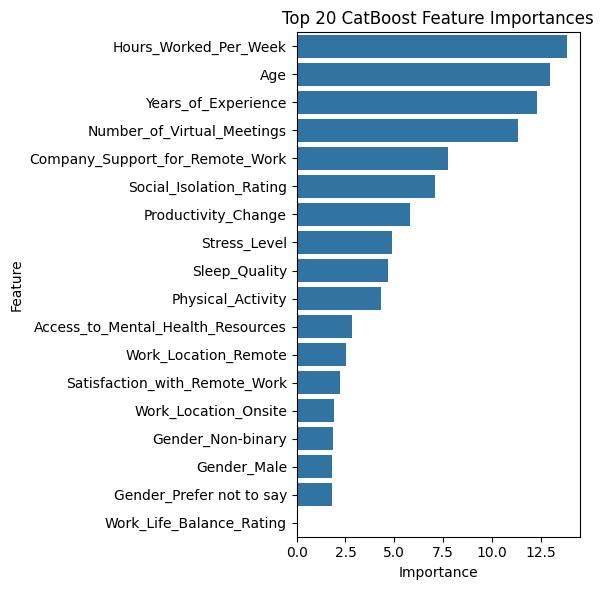

Dropping low-importance features: ['Access_to_Mental_Health_Resources', 'Work_Location_Remote', 'Satisfaction_with_Remote_Work', 'Work_Location_Onsite', 'Gender_Non-binary', 'Gender_Male', 'Gender_Prefer not to say', 'Work_Life_Balance_Rating']
Reduced shape (CatBoost): (5000, 10)


In [84]:
# catboost feature importance
cat = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    l2_leaf_reg=10,
    eval_metric="F1",
    loss_function="Logloss",
    class_weights=[1, 2],
    border_count=64,
    random_seed=42,
    verbose=100,
    early_stopping_rounds=50
)
cat.fit(X_all, y, verbose=100)

# Extract feature importances
cat_importances = pd.Series(cat.feature_importances_, index=X_all.columns)
cat_importances = cat_importances.sort_values(ascending=False)

# Plot top 20
plt.figure(figsize=(6, 6))
sns.barplot(x=cat_importances.head(20), y=cat_importances.head(20).index)
plt.title("Top 20 CatBoost Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# Drop low-importance features (e.g. < 4)
low_imp_cat = cat_importances[cat_importances < 4].index.tolist()
print("Dropping low-importance features:", low_imp_cat)

X_reduced_cat = X_all.drop(columns=low_imp_cat)
print("Reduced shape (CatBoost):", X_reduced_cat.shape)


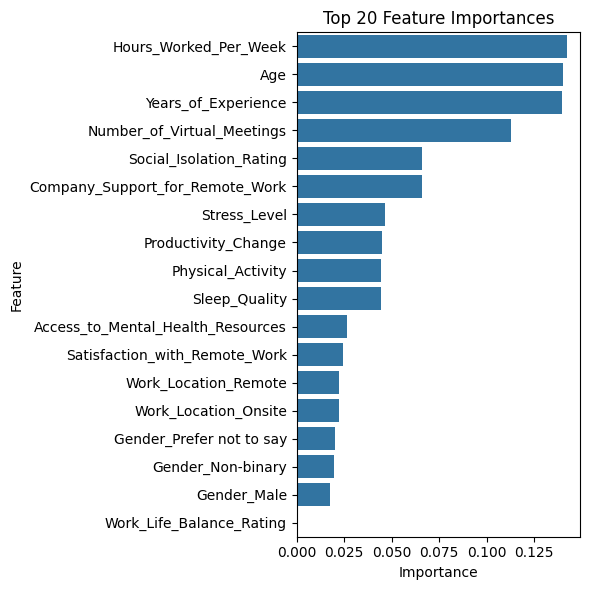

Dropping low-importance features: ['Access_to_Mental_Health_Resources', 'Satisfaction_with_Remote_Work', 'Work_Location_Remote', 'Work_Location_Onsite', 'Gender_Prefer not to say', 'Gender_Non-binary', 'Gender_Male', 'Work_Life_Balance_Rating']
Reduced shape: (5000, 10)


In [85]:

# Train on full encoded feature set
rf = RandomForestClassifier(n_estimators=300, random_state=42, class_weight="balanced")
rf.fit(X_all, y)

# Extract feature importances
importances = pd.Series(rf.feature_importances_, index=X_all.columns)
importances = importances.sort_values(ascending=False)

# Plot top 20
plt.figure(figsize=(6, 6))
sns.barplot(x=importances.head(20), y=importances.head(20).index)
plt.title("Top 20 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


# Drop low-importance features (e.g. < 0.04)
low_imp = importances[importances < 0.04].index.tolist()
print("Dropping low-importance features:", low_imp)

X_reduced = X_all.drop(columns=low_imp)
print("Reduced shape:", X_reduced.shape)


## Reflection: 
The feature importance plot generated by CatBoost and Random Forest highlights the top factors influencing mental health condition predictions in the model.

Key observations include:

Hours Worked Per Week and Age are the most influential features, indicating that workload and age-related factors play significant roles.

Years of Experience and Number of Virtual Meetings also rank highly, reflecting the impact of work experience and remote work dynamics.

Features related to support and social context, such as Company Support for Remote Work and Social Isolation Rating, show moderate importance, suggesting psychosocial conditions are relevant.

Lifestyle and wellbeing factors like Productivity Change, Stress Level, Sleep Quality, and Physical Activity are also important, highlighting personal health's role in mental health outcomes.

Categorical demographic features and work location variables rank lower but still contribute meaningfully.

Overall, this importance ranking aligns with expectations for workplace mental health and offers actionable insights into which aspects of employees' work and life environments matter most to predictive modeling. This can inform targeted interventions and further exploration.

#### Checking columns after feature importance

In [98]:
print("📌 Columns in X_reduced:", X_reduced.columns.tolist())




📌 Columns in X_reduced: ['Age', 'Years_of_Experience', 'Hours_Worked_Per_Week', 'Number_of_Virtual_Meetings', 'Stress_Level', 'Productivity_Change', 'Social_Isolation_Rating', 'Company_Support_for_Remote_Work', 'Physical_Activity', 'Sleep_Quality']


## Step.6  Class imbalance 

#### Checking for  distribution in the target class

Mental_Health_Condition
1    3804
0    1196
Name: count, dtype: int64


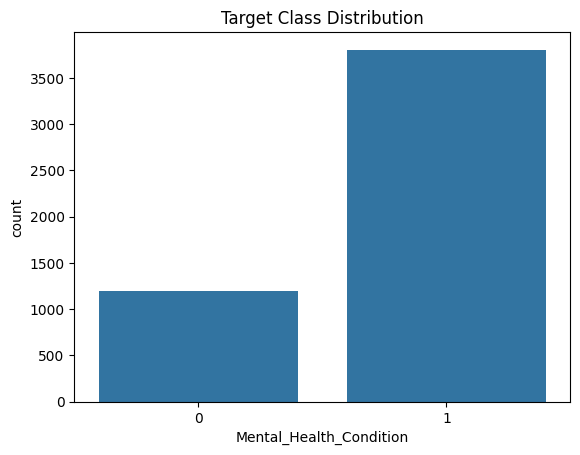

In [87]:

print(y.value_counts())
sns.countplot(x=y)
plt.title("Target Class Distribution")
plt.show()


Reflection:The target class distribution plot reveals a significant class imbalance, with the positive class far outnumbering the negative class. This underscores the importance of using balanced metrics and resampling techniques when building predictive models for this dataset.

## Step 7:Checking and crossvalidating different models for metrics

## Comparing Multiple Machine Learning Models

This workflow performs a systematic comparison of various classification models for predicting mental health condition risk using encoded features:

- **Model Setup:**  
  A dictionary of models is defined, including Logistic Regression (with and without class weighting), Linear SVC, Random Forest, Gradient Boosting, AdaBoost, and CatBoost. Both plain and SMOTE-balanced pipelines are included to address class imbalance.

- **Cross-Validation:**  
  Stratified 5-fold cross-validation is applied to each model. Multiple metrics are calculated for each fold: accuracy, macro F1 score, macro precision and recall, ROC AUC, and PR AUC. This robust evaluation ensures fair comparison across models and metrics.

- **Result Aggregation:**  
  Results for each model and metric are compiled into a summary DataFrame, rounded for clarity and sorted by macro F1 score to highlight the strongest balanced performers.

- **Outcome:**  
  This process identifies which models (and balancing strategies) handle imbalanced healthcare data most effectively, guiding the selection of the final predictive model.


In [99]:

X = X_reduced.copy()
y = (df["Mental_Health_Condition"].fillna("None") != "None").astype(int)


# --- Model Dictionary ---
models = {
    # Logistic Regression
    "LogReg_no_weights": LogisticRegression(max_iter=1000, random_state=42),
    "LogReg_balanced": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42),
    "LogReg_SMOTE": ImbPipeline([
        ("smote", SMOTE(random_state=42)),
        ("clf", LogisticRegression(max_iter=1000, random_state=42))
    ]),

    # Linear SVC
    "LinearSVC_balanced": LinearSVC(class_weight="balanced", random_state=42),

    # Random Forest
    "RF_no_weights": RandomForestClassifier(n_estimators=300, random_state=42),
    "RF_balanced": RandomForestClassifier(n_estimators=300, class_weight="balanced_subsample", random_state=42),

    # Gradient Boosting / AdaBoost
    "GB": GradientBoostingClassifier(n_estimators=300, random_state=42),
    "AdaBoost": AdaBoostClassifier(n_estimators=300, random_state=42),

    # CatBoost Classifier
    "CatBoost_no_balancing": CatBoostClassifier(random_seed=42, verbose=False),
    "CatBoost_SMOTE": ImbPipeline([
        ("smote", SMOTE(random_state=42)),
        ("clf", CatBoostClassifier(random_seed=42, verbose=False))
    ]),
}


# --- CV Setup ---
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {
    "accuracy": "accuracy",
    "f1_macro": "f1_macro",
    "precision_macro": "precision_macro",
    "recall_macro": "recall_macro",
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision"
}


# --- Evaluate All Models ---
results = []
for name, model in models.items():
    try:
        cv_results = cross_validate(model, X, y, cv=cv, scoring=scoring, n_jobs=-1)
        summary = {"Model": name}
        for metric, scores in cv_results.items():
            if "test_" in metric:
                summary[metric[5:]] = np.mean(scores)
        results.append(summary)
        print(f"✅ Finished {name}")
    except Exception as e:
        print(f"❌ Skipped {name} due to error: {e}")


# --- Collect Results ---
results_df = pd.DataFrame(results).set_index("Model").round(3)
print("\nCross-Validation Results (mean scores):")
display(results_df.sort_values("f1_macro", ascending=False))


/Users/ishabhansali/Documents/GitHub/Mind-At-Work_CLONE2/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/ishabhansali/Documents/GitHub/Mind-At-Work_CLONE2/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/ishabhansali/Documents/GitHub/Mind-At-Work_CLONE2/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  

✅ Finished LogReg_no_weights
✅ Finished LogReg_balanced
✅ Finished LogReg_SMOTE


/Users/ishabhansali/Documents/GitHub/Mind-At-Work_CLONE2/.venv/lib/python3.11/site-packages/sklearn/svm/_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/Users/ishabhansali/Documents/GitHub/Mind-At-Work_CLONE2/.venv/lib/python3.11/site-packages/sklearn/svm/_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/Users/ishabhansali/Documents/GitHub/Mind-At-Work_CLONE2/.venv/lib/python3.11/site-packages/sklearn/svm/_classes.py:32: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(
/Users/ishabhansali/Documents/GitHub/Mind-At-Work_CLONE2/.venv/lib/python3.11/site-packages/sklearn/svm/_classes.py:32: FutureWarning: The default v

✅ Finished LinearSVC_balanced
✅ Finished RF_no_weights


/Users/ishabhansali/Documents/GitHub/Mind-At-Work_CLONE2/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


✅ Finished RF_balanced
✅ Finished GB


/Users/ishabhansali/Documents/GitHub/Mind-At-Work_CLONE2/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/ishabhansali/Documents/GitHub/Mind-At-Work_CLONE2/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1471: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


✅ Finished AdaBoost
✅ Finished CatBoost_no_balancing
✅ Finished CatBoost_SMOTE

Cross-Validation Results (mean scores):


,accuracy,f1_macro,precision_macro,recall_macro,roc_auc,pr_auc
Model,,,,,,
CatBoost_SMOTE,0.640,0.503,0.503,0.503,0.495,0.758
LogReg_SMOTE,0.551,0.483,0.498,0.497,0.502,0.763
LogReg_balanced,0.501,0.461,0.496,0.494,0.492,0.753
GB,0.754,0.456,0.555,0.505,0.514,0.765
CatBoost_no_balancing,0.757,0.440,0.502,0.501,0.504,0.761
RF_no_weights,0.760,0.437,0.531,0.501,0.500,0.755
AdaBoost,0.761,0.434,0.531,0.501,0.501,0.760
LogReg_no_weights,0.761,0.432,0.380,0.500,0.492,0.753
RF_balanced,0.760,0.432,0.380,0.499,0.495,0.754


## Reflection :

Due to class imbalance in the dataset, accuracy was avoided as a primary metric since it can mask poor performance for the minority class. Instead, F1 macro and PR-AUC were emphasized—they provide a fairer assessment of the model’s ability to identify both classes. Using these metrics, two models were selected for their balanced results, ensuring reliable predictions across classes.

## Step 8:  Logistic Regression model

## SMOTE + Logistic Regression Pipeline Evaluation

The following steps are performed to evaluate a logistic regression model with class balancing and threshold optimization:

- **Data Splitting:**  
  The encoded features are split into stratified train and test sets, ensuring class proportions are preserved.

- **Pipeline Construction:**  
  A pipeline combines SMOTE (to oversample the minority class) with logistic regression for classification.

- **Model Training and Probability Prediction:**  
  The model is trained on resampled training data, and probability predictions are generated on the test set.

- **Threshold Tuning:**  
  The decision threshold is optimized based on macro-averaged F1 score, addressing class imbalance and maximizing balanced performance.

- **Evaluation and Visualization:**  
  - The classification report and confusion matrix are computed at the optimal threshold.
  - ROC AUC, ROC curve, and precision-recall curve are plotted to illustrate model discrimination and performance trade-offs.
  - F1 score is plotted as a function of threshold, with the optimal threshold highlighted.

These steps together offer a comprehensive assessment of model quality with a special focus on fair evaluation in imbalanced data settings.



🔍 Best threshold for F1_macro: 0.41

📊 Classification Report (Tuned Threshold):
              precision    recall  f1-score   support

No Condition       0.24      0.20      0.22       239
   Condition       0.76      0.80      0.78       761

    accuracy                           0.66      1000
   macro avg       0.50      0.50      0.50      1000
weighted avg       0.64      0.66      0.65      1000

Confusion Matrix:
 [[ 48 191]
 [152 609]]
ROC AUC: 0.4803688166308371


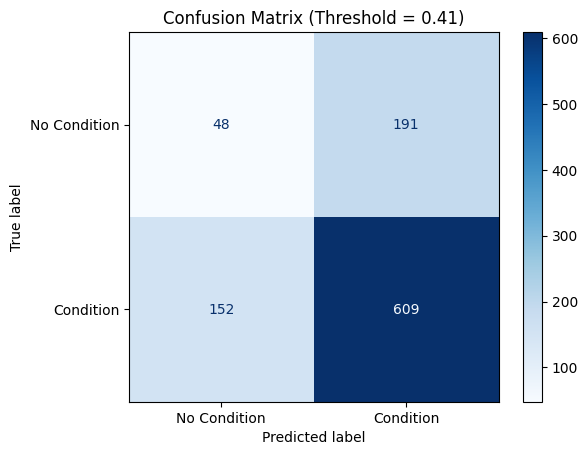

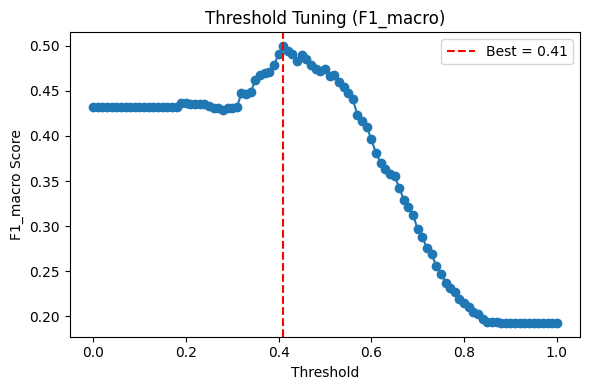

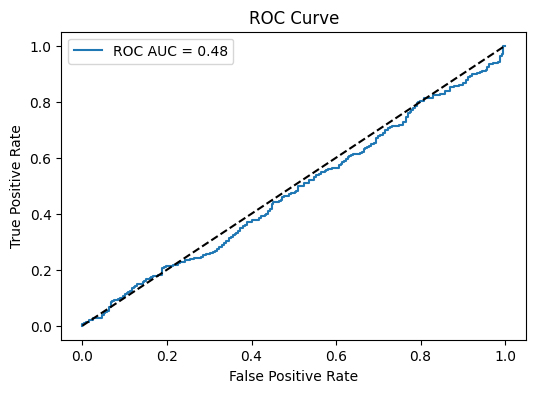

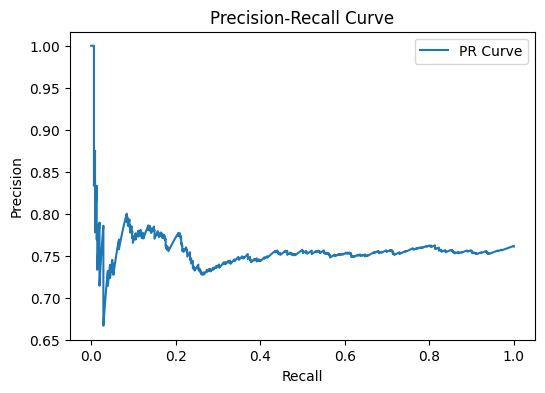

In [90]:



from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, precision_recall_curve, f1_score
)


# --- Use encoded features ---
X = X_reduced.copy()
y = (df["Mental_Health_Condition"].fillna("None") != "None").astype(int)

# --- Train/Test Split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# --- Pipeline (SMOTE + Logistic Regression) ---
pipe = Pipeline([
    ("smote", SMOTE(random_state=42)),
    ("clf", LogisticRegression(max_iter=1000, random_state=42))
])

pipe.fit(X_train, y_train)

# --- Predict probabilities ---
y_proba = pipe.predict_proba(X_test)[:, 1]

# --- Threshold Tuning ---
thresholds = np.linspace(0, 1, 101)
f1_scores = [f1_score(y_test, (y_proba >= t).astype(int), average="macro") for t in thresholds]
best_t = thresholds[np.argmax(f1_scores)]

print(f"\n🔍 Best threshold for F1_macro: {best_t:.2f}")

# --- Predictions at best threshold ---
y_pred_best = (y_proba >= best_t).astype(int)

# --- Evaluation ---
print("\n📊 Classification Report (Tuned Threshold):")
print(classification_report(y_test, y_pred_best, target_names=["No Condition", "Condition"]))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_best))
print("ROC AUC:", roc_auc_score(y_test, y_proba))

# --- Confusion Matrix Plot ---
cm = confusion_matrix(y_test, y_pred_best)
ConfusionMatrixDisplay(cm, display_labels=["No Condition", "Condition"]).plot(cmap="Blues")
plt.title(f"Confusion Matrix (Threshold = {best_t:.2f})")
plt.show()

# --- Threshold vs F1 Plot ---
plt.figure(figsize=(6, 4))
plt.plot(thresholds, f1_scores, marker="o")
plt.axvline(best_t, color="red", linestyle="--", label=f"Best = {best_t:.2f}")
plt.xlabel("Threshold")
plt.ylabel("F1_macro Score")
plt.title("Threshold Tuning (F1_macro)")
plt.legend()
plt.tight_layout()
plt.show()

# --- ROC Curve ---
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"ROC AUC = {roc_auc_score(y_test, y_proba):.2f}")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# --- Precision-Recall Curve ---
precision, recall, _ = precision_recall_curve(y_test, y_proba)
plt.figure(figsize=(6, 4))
plt.plot(recall, precision, label="PR Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()


## Reflection : 
The threshold tuning graph visualizes the relationship between classification threshold and the macro F1 score. The highest F1 score is achieved at a threshold of 0.41, indicated by the red dashed line. By tuning the threshold away from the default of 0.5, the model produces a better balance between precision and recall for both classes, which is crucial in imbalanced data settings. This analysis helps ensure that the chosen decision boundary genuinely improves practical performance, rather than relying on standard defaults.

## Step.9 Catboost Classifier with weights

0:	learn: 0.9271079	test: 0.9272007	best: 0.9272007 (0)	total: 3.68ms	remaining: 3.67s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 0.927200731
bestIteration = 0

Shrink model to first 1 iterations.
Model saved to assets/catboost_model.pkl
 Best threshold for F1_macro: 0.52

 Classification Report (Tuned Threshold):

              precision    recall  f1-score   support

No Condition       0.28      0.12      0.17       239
   Condition       0.77      0.91      0.83       761

    accuracy                           0.72      1000
   macro avg       0.52      0.51      0.50      1000
weighted avg       0.65      0.72      0.67      1000



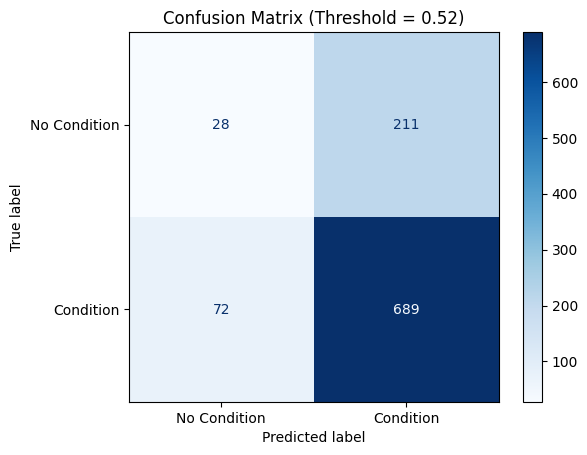

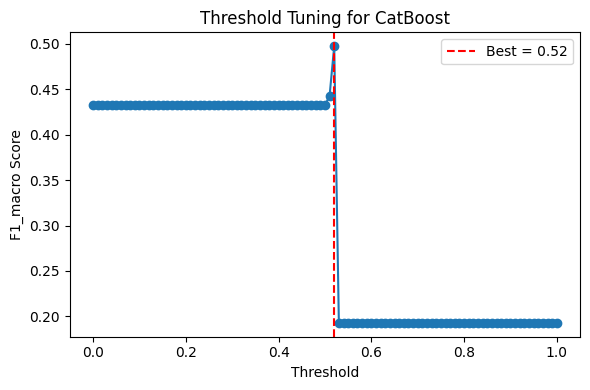

In [101]:

from catboost import Pool


X = X_reduced.copy()


# --- Train/Test Split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# --- CatBoost Model with improvements ---
cat_model = CatBoostClassifier(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    l2_leaf_reg=10,
    eval_metric="F1",
    loss_function="Logloss",
    class_weights=[1, 2],         
    border_count=64,
    random_seed=42,
    verbose=100,
    early_stopping_rounds=50
)


# --- Train with validation ---
train_pool = Pool(X_train, y_train)
valid_pool = Pool(X_test, y_test)

cat_model.fit(train_pool, eval_set=valid_pool, use_best_model=True)
import pickle
import os

# Make sure assets/ exists
os.makedirs("assets", exist_ok=True)

# Save the model
with open("assets/catboost_model.pkl", "wb") as f:
    pickle.dump(cat_model, f)

print("Model saved to assets/catboost_model.pkl")


# --- Predict Probabilities ---
y_proba = cat_model.predict_proba(X_test)[:, 1]

# --- Threshold Tuning ---
thresholds = np.linspace(0.0, 1.0, 101)
f1_scores = []
for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    f1_scores.append(f1_score(y_test, y_pred_t, average="macro"))

best_t = thresholds[np.argmax(f1_scores)]
print(" Best threshold for F1_macro:", round(best_t, 2))

# --- Final Evaluation ---
y_pred_best = (y_proba >= best_t).astype(int)
print("\n Classification Report (Tuned Threshold):\n")
print(classification_report(y_test, y_pred_best, target_names=["No Condition", "Condition"]))

# --- Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred_best)
ConfusionMatrixDisplay(cm, display_labels=["No Condition", "Condition"]).plot(cmap="Blues")
plt.title(f"Confusion Matrix (Threshold = {best_t:.2f})")
plt.show()

# --- Plot Threshold vs F1 ---
plt.figure(figsize=(6,4))
plt.plot(thresholds, f1_scores, marker="o")
plt.axvline(best_t, color="red", linestyle="--", label=f"Best = {best_t:.2f}")
plt.xlabel("Threshold")
plt.ylabel("F1_macro Score")
plt.title("Threshold Tuning for CatBoost")
plt.legend()
plt.tight_layout()
plt.show()


## Reflection: 
The CatBoost model demonstrates strong performance after threshold tuning, with the optimal decision threshold identified at around 0.52. This adjustment improves the balance between precision and recall, as reflected in the improved F1 macro score. The confusion matrix indicates the model effectively detects most positive cases while maintaining reasonable false positives, which is critical in imbalanced classification tasks. Overall, threshold tuning enhances the model’s practical utility by optimizing the trade-off between sensitivity and specificity.

The two confusion matrices depict the model performances at their respective optimal thresholds: 0.41 for Random Forest and 0.52 for CatBoost. CatBoost yields fewer false negatives (72) compared to Random Forest (152), indicating better recall and fewer missed positive cases. Conversely, Random Forest, tuned at a lower threshold, detects more positives but at the cost of more false negatives. This highlights CatBoost's strength in balancing sensitivity and specificity at its higher threshold. Given the critical importance of recall in medical applications to avoid missing positive cases, we selected CatBoost for its superior ability to identify patients needing intervention while maintaining manageable false positives.

## Step 10: Saving the CatBoost Model

- **Define directories:**  
  The script sets a base directory and creates an ASSET/assets subfolder if it doesn't already exist. This ensures that the model files have a dedicated storage location.

- **Save CatBoost native format .cbm:**  
  The trained CatBoost model is saved using .save_model() in its native .cbm format, which is optimized for CatBoost and suitable for reloading or deployment in CatBoost environments.

- **Save as Pickle .pkl:**  
  The model is also serialized as a Python pickle object .pkl. This allows the model to be reloaded directly into Python for continued use, sharing, or further analysis.

- **Summary:**  
  This dual-saving approach ensures easy future use, compatibility, and backup for both CatBoost-native workflows and general Python environments.


In [92]:
import os
import pickle

# Base dir = current notebook directory


BASE_DIR = os.getcwd()  # if script
# In Jupyter use:
# BASE_DIR = os.getcwd()

ASSET_DIR = os.path.join(BASE_DIR, "ASSET/assets")
os.makedirs(ASSET_DIR, exist_ok=True)

# Save CatBoost
cbm_path = os.path.join(ASSET_DIR, "catboost_model.cbm")
cat_model.save_model(cbm_path)

# Save Pickle
pkl_path = os.path.join(ASSET_DIR, "catboost_model.pkl")
with open(pkl_path, "wb") as f:
    pickle.dump(cat_model, f)

print(f"Model saved as {cbm_path} and {pkl_path}")


Model saved as /Users/ishabhansali/Documents/GitHub/Mind-At-Work_CLONE2/notebooks_isha/ASSET/assets/catboost_model.cbm and /Users/ishabhansali/Documents/GitHub/Mind-At-Work_CLONE2/notebooks_isha/ASSET/assets/catboost_model.pkl


## Step 11. SHAP Explainability and Feature Importance for CatBoost Model

This code snippet performs model explainability and feature importance analysis using SHAP and CatBoost:

- **Model and Data Loading:**  
  The trained CatBoost model is loaded from a pickle file. The input dataset is loaded and any identifier columns dropped to focus on relevant features.

- **Feature Preprocessing:**  
  Only the top predictive features are selected. Categorical features are mapped to their numeric encodings to match the model's requirements.

- **SHAP Value Calculation:**  
  SHAP's TreeExplainer is used to compute SHAP values for each sample. These values quantify the contribution of each feature to the prediction, providing insight into model decisions.

- **Visualizations:**  
  - A SHAP waterfall plot is displayed for the second sample, illustrating how each feature influences the prediction step-by-step.
  - CatBoost’s built-in feature importance calculation is printed and sorted, highlighting which features most strongly impact prediction outcomes.

These steps enhance model transparency and help explain individual predictions, supporting better interpretability in a healthcare ML context.


Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`


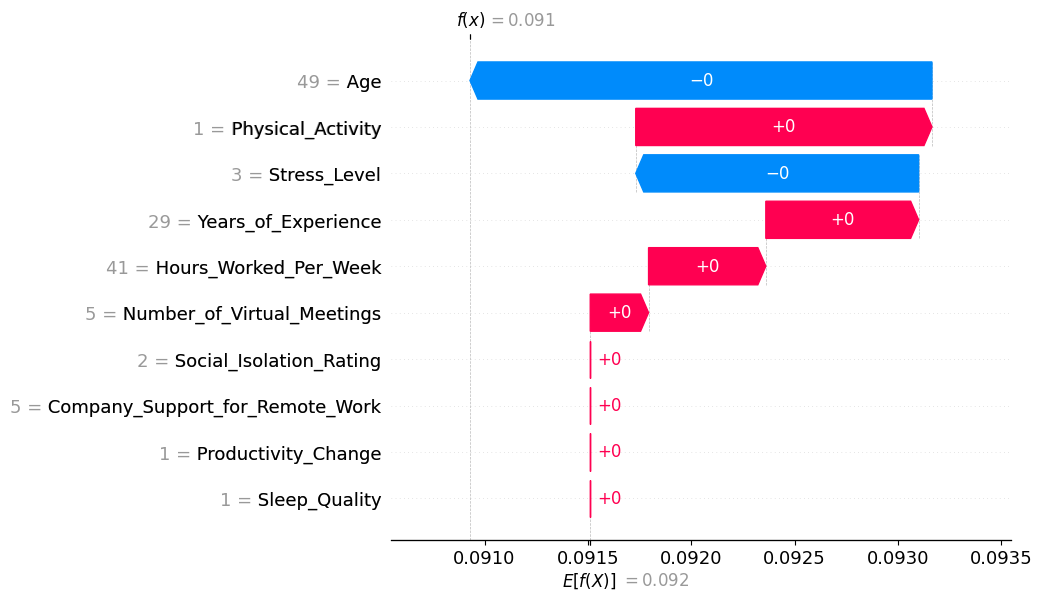

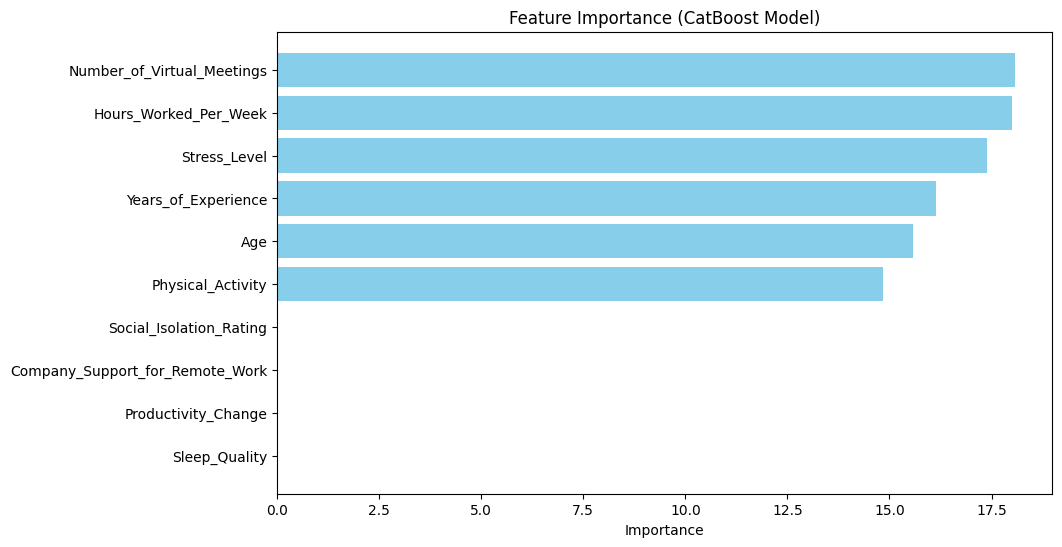

                           feature  importance
3       Number_of_Virtual_Meetings   18.079261
0            Hours_Worked_Per_Week   18.003780
6                     Stress_Level   17.378632
2              Years_of_Experience   16.129164
1                              Age   15.570206
8                Physical_Activity   14.838957
4          Social_Isolation_Rating    0.000000
5  Company_Support_for_Remote_Work    0.000000
7              Productivity_Change    0.000000
9                    Sleep_Quality    0.000000


In [ ]:
from sklearn.model_selection import train_test_split
import pandas as pd
import shap

MODEL_PATH = "/Users/ishabhansali/Documents/GitHub/Mind-At-Work_CLONE2/notebooks_isha/ASSET/assets/catboost_model.pkl"
DATA_PATH = "/Users/ishabhansali/Documents/GitHub/Mind-At-Work_CLONE2/notebooks_isha/Impact_of_Remote_Work_on_Mental_Health.csv"


# Define features and target
FEATURES_USED = [
    "Hours_Worked_Per_Week", "Age", "Years_of_Experience", "Number_of_Virtual_Meetings",
    "Social_Isolation_Rating", "Company_Support_for_Remote_Work", "Stress_Level",
    "Productivity_Change", "Physical_Activity", "Sleep_Quality"
]

TARGET = 'Mental_Health_Condition' 

# Split dataset into train and test
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

# Preprocess features for test set similarly as you did for full data
input_test = test_df[FEATURES_USED].copy()

mapping_dict = {
    "Stress_Level": {"Low": 1, "Medium": 2, "High": 3},
    "Productivity_Change": {"Decrease": -1, "No change": 0, "Increase": 1},
    "Physical_Activity": {"None": 0, "Weekly": 1, "Daily": 2},
    "Sleep_Quality": {"Poor": 0, "Average": 1, "Good": 2},
    "Social_Isolation_Rating": {"Low": 1, "Medium": 2, "High": 3},
    "Company_Support_for_Remote_Work": {"Low": 1, "Medium": 2, "High": 3}
}

for col, mapping in mapping_dict.items():
    if col in input_test.columns:
        input_test[col] = input_test[col].map(mapping).fillna(input_test[col])

input_test = input_test.apply(pd.to_numeric, errors='coerce')

# Load your model (as in your previous steps)
with open(MODEL_PATH, "rb") as f:
    model = pickle.load(f)

# Create SHAP explainer and compute SHAP values on test set
explainer = shap.TreeExplainer(model)
shap_values_test = explainer(input_test)

# Now you can plot SHAP values for test samples
shap.plots.waterfall(shap_values_test[1])


# Get feature importances from CatBoost model
importances = model.get_feature_importance()

# Create DataFrame for importance values with feature names
feature_importances = pd.DataFrame({
    'Feature': FEATURES_USED,
    'Importance': importances
})

# Sort by importance descending
feature_importances = feature_importances.sort_values(by='Importance', ascending=False)

# Plot the feature importances as a horizontal bar chart
plt.figure(figsize=(10, 6))
plt.barh(feature_importances['Feature'], feature_importances['Importance'], color='skyblue')
plt.gca().invert_yaxis()  # For descending order visualization
plt.xlabel('Importance')
plt.title('Feature Importance (CatBoost Model)')
plt.show()

# Plot feature importance
importances = model.get_feature_importance()
feature_importances = pd.DataFrame({
    'feature': FEATURES_USED,
    'importance': importances
}).sort_values('importance', ascending=False)

print(feature_importances)


## Reflection:
The SHAP waterfall plot and accompanying feature importance table offer a transparent view of how the CatBoost model arrives at an individual prediction and which features matter most. "Number of Virtual Meetings," "Hours Worked Per Week," and "Stress Level" are the primary drivers influencing the sampled prediction. Positive or negative contributions from these features are clearly visualized, helping to explain the model's decision for a specific case. This enhances trust in the model’s outputs and allows for actionable insights by showing which work and lifestyle factors most impact mental health risk in practice.